<a href="https://colab.research.google.com/github/heiseii/analisis-ventas/blob/script/scripts/analisis-datos.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Created dummy file: datos/ventas.csv
Ventas totales: 560
Producto más vendido: A
Graph saved to resultados/grafico_ventas.png


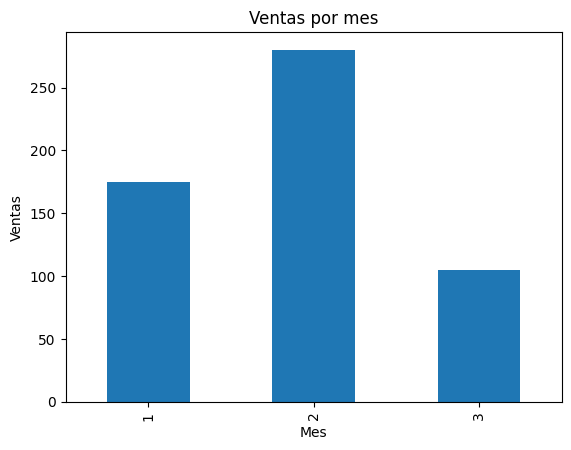

In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import os

# Ensure the 'datos' directory exists
if not os.path.exists('datos'):
    os.makedirs('datos')

# Create a dummy ventas.csv file if it doesn't exist
file_path = 'datos/ventas.csv'
if not os.path.exists(file_path):
    dummy_data = {
        'fecha': ['2023-01-01', '2023-01-15', '2023-02-01', '2023-02-10', '2023-03-05'],
        'producto': ['A', 'B', 'A', 'C', 'B'],
        'cantidad': [10, 5, 12, 8, 7],
        'amount': [100, 75, 120, 160, 105]
    }
    dummy_df = pd.DataFrame(dummy_data)
    dummy_df.to_csv(file_path, index=False)
    print(f"Created dummy file: {file_path}")

#Leer dataset
df = pd.read_csv(file_path)

#Calcular ventas totales
ventas_totales = df["amount"].sum()

#Producto más vendido
producto_mas_vendido = df.groupby("producto")["cantidad"].sum().idxmax()

#Ventas por mes
df["fecha"] = pd.to_datetime(df["fecha"])
df["mes"] = df["fecha"].dt.month

ventas_mes = df.groupby("mes")["amount"].sum()

#Mostrar resultados
print("Ventas totales:", ventas_totales)
print("Producto más vendido:", producto_mas_vendido)

#Generar gráfico
ventas_mes.plot(kind="bar")

plt.title("Ventas por mes")
plt.xlabel("Mes")
plt.ylabel("Ventas")

#Guardar gráfico

# Ensure the 'resultados' directory exists
if not os.path.exists('resultados'):
    os.makedirs('resultados')

plt.savefig("resultados/grafico_ventas.png")
print("Graph saved to resultados/grafico_ventas.png")